In [2]:
# label_data.py
import pandas as pd

# --- Timestamps based on your notes ---
NORMAL_START_TIME = 1758473973
NORMAL_END_TIME   = 1758474654

SYN_FLOOD_START_TIME = 1758474655  # Assumed to start right after normal traffic
SYN_FLOOD_END_TIME   = 1758474744

ICMP_FLOOD_START_TIME = 1758475466
ICMP_FLOOD_END_TIME   = 1758475812

# --- Define the labels ---
LABEL_BENIGN = 0
LABEL_SYN_FLOOD = 1
LABEL_ICMP_FLOOD = 2

def get_label(timestamp):
    """Assigns a label based on the timestamp of the flow."""
    if NORMAL_START_TIME <= timestamp <= NORMAL_END_TIME:
        return LABEL_BENIGN
    elif SYN_FLOOD_START_TIME <= timestamp <= SYN_FLOOD_END_TIME:
        return LABEL_SYN_FLOOD
    elif ICMP_FLOOD_START_TIME <= timestamp <= ICMP_FLOOD_END_TIME:
        return LABEL_ICMP_FLOOD
    else:
        return -1 # Mark as unlabeled/unclassified

# --- Main script logic ---
if __name__ == "__main__":
    input_csv = 'flow_data.csv'
    output_csv = 'labeled_flow_data.csv'

    print(f"Reading raw data from '{input_csv}'...")
    df = pd.read_csv(input_csv)
    
    # Apply the labeling function to create the new 'label' column
    print("Applying labels based on your timestamps...")
    df['label'] = df['timestamp'].apply(get_label)

    # Filter out any unlabeled data
    labeled_df = df[df['label'] != -1].copy()

    print("\nLabeling complete. Here are the counts for each label:")
    print(labeled_df['label'].value_counts())
    print(f"({LABEL_BENIGN}=Benign, {LABEL_SYN_FLOOD}=SYN Flood, {LABEL_ICMP_FLOOD}=ICMP Flood)")

    # Save the new DataFrame to a new file
    labeled_df.to_csv(output_csv, index=False)
    print(f"\n✅ Labeled data saved successfully to '{output_csv}'")

Reading raw data from 'flow_data.csv'...
Applying labels based on your timestamps...

Labeling complete. Here are the counts for each label:
label
1    2256
0     138
2      55
Name: count, dtype: int64
(0=Benign, 1=SYN Flood, 2=ICMP Flood)

✅ Labeled data saved successfully to 'labeled_flow_data.csv'


Loading 'labeled_flow_data.csv'...
Data split into training and testing sets.
Training the RandomForest model...
Model training complete.

--- Model Evaluation ---
Model Accuracy: 99.86%

Classification Report:
              precision    recall  f1-score   support

      Benign       0.98      1.00      0.99        41
   SYN Flood       1.00      1.00      1.00       677
  ICMP Flood       1.00      0.94      0.97        17

    accuracy                           1.00       735
   macro avg       0.99      0.98      0.99       735
weighted avg       1.00      1.00      1.00       735



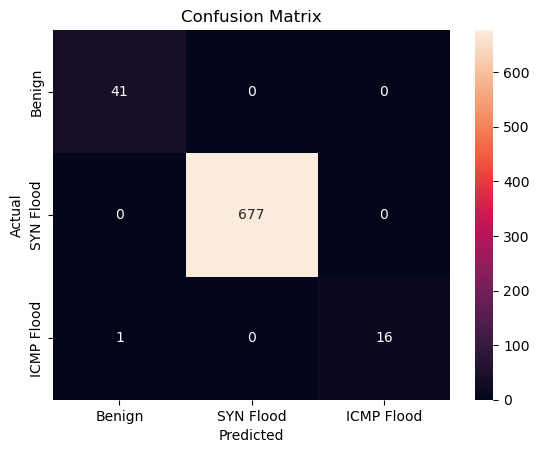


✅ Model saved successfully as 'intelligent_ddos_model.joblib'


In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load your labeled dataset
print("Loading 'labeled_flow_data.csv'...")
df = pd.read_csv('labeled_flow_data.csv')

# Make sure there are no missing values
df.fillna(0, inplace=True)

# 2. Define your features (X) and your target (y)
features = [
    'packet_count', 'byte_count', 'syn_count', 'fin_count', 
    'rst_count', 'ack_count', 'icmp_count', 'duration_sec'
]
X = df[features]
y = df['label']

# 3. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Data split into training and testing sets.")

# 4. Initialize and train the model
print("Training the RandomForest model...")
# class_weight='balanced' helps the model learn better from imbalanced datasets
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
print("Model training complete.")

# 5. Evaluate the model's performance
print("\n--- Model Evaluation ---")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'SYN Flood', 'ICMP Flood']))

# Display a confusion matrix to see the results visually
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['Benign', 'SYN Flood', 'ICMP Flood'], yticklabels=['Benign', 'SYN Flood', 'ICMP Flood'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# 6. Save the trained model to a file
model_filename = 'intelligent_ddos_model.joblib'
joblib.dump(model, model_filename)
print(f"\n✅ Model saved successfully as '{model_filename}'")